<!--- ![tudd-neu.png](attachment:tudd-neu.png) --->
<img src="tudd-neu.png" alt="drawing" width="200"/>

Professur für Angewandte Umweltsystemanalyse an der TU Dresden <br/>
Prof. Dr.-Ing. habil. Olaf Kolditz <br/>
***Hydroinformatik (UW-BHW-414)*** <br/>
*[Lehre-Webseite](https://www.ufz.de/index.php?de=52702)*

**Übung: EX09 Jupyter Notebook**

In dieser Übung werden die beiden letzten Übungen, Funktionsberechnungen mit C++ und Python, in einem Jupyter Notebook zusammengeführt. Dies zeigt einen der Vorteile von Jupyter Notebook, in dem verschiedene Aufgaben in einer Web-Umgebung zusammengeführt und ausgeführt werden.

Inhalt:
- Funktionsberechnung mit dem C++ code und Ergebnisse als Datei schreiben
- Funktionsberechnung mit dem Python code
- Vergleich der Ergebnisse
- KI Vorschlag für Funktionsberechnungen und Vergleich

***EX08a: Funktionsberechnung mit C++***

In [1]:
!g++ EX08a-function.cpp
!a.exe

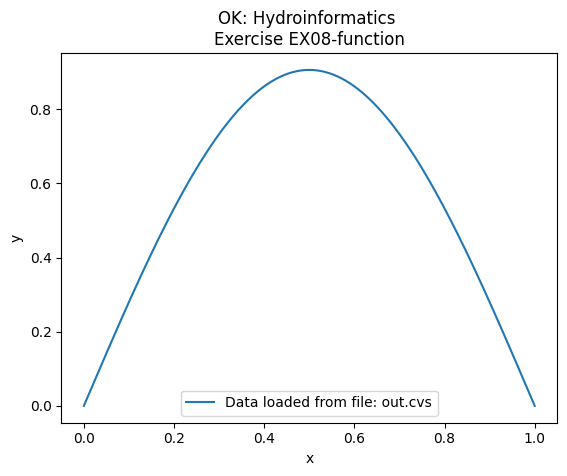

In [2]:
import matplotlib.pyplot as plt
import csv
import numpy as np

x1 = []
y1 = []

with open('out.csv','r') as csvfile:
    plots = csv.reader(csvfile, delimiter=',')
    for row in plots:
        x1.append(float(row[0]))
        y1.append(float(row[1]))

plt.plot(x1,y1, label='Data loaded from file: out.cvs')
plt.xlabel('x')
plt.ylabel('y')
plt.title('OK: Hydroinformatics \nExercise EX08-function')
plt.legend()
plt.savefig("ex08-function.png")
plt.show()

# Convert to numpy arrays
x1 = np.array(x1)
y1 = np.array(y1)

***EX08d: Funktionsberechnung mit Python***

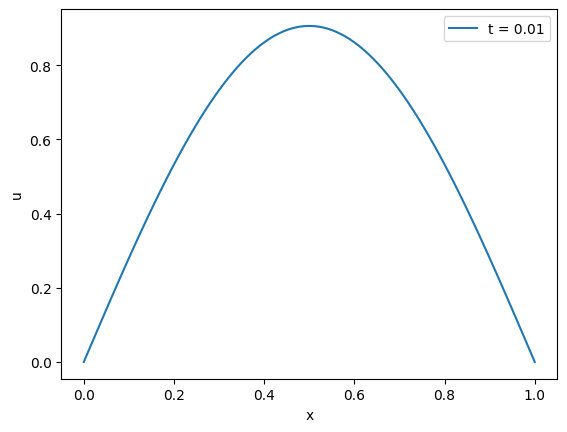

In [5]:
import math
import matplotlib.pylab as plt

PI = 3.14159265358979323846
numPoints = 100
alpha = 1.0
#t = [0.001, 0.1, 0.5, 0.7, 1.0, 2.0]
t = [0.01]

# Precompute x coordinates (same for all curves)
x2 = [float(i) / numPoints for i in range(numPoints + 1)]

for n in t:
    #y2 = [math.sin(PI * xi) * math.exp(-alpha * n * n) for xi in x2]
    y2 = [math.sin(PI * xi) * math.exp(-alpha * PI * PI * n) for xi in x2]
    plt.plot(x2, y2, label=f't = {n}')   # Add label

plt.xlabel('x')
plt.ylabel('u')
plt.legend()            # Show the labels
plt.axis('tight')
plt.savefig("ex08c-function.png")
plt.show()

***Vergleich der beiden Funktionen (C++ und Python):***

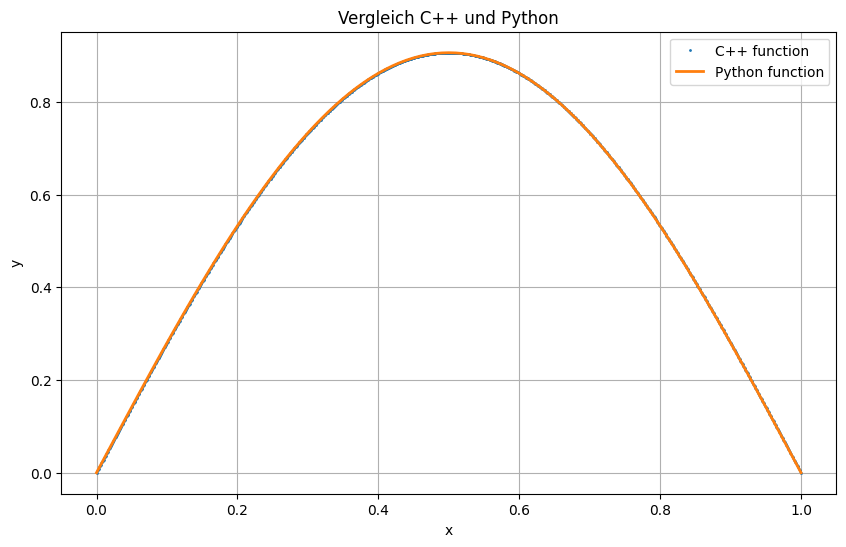

In [6]:
# -------- 5. Visual comparison (CSV vs best theoretical curve) --------
plt.figure(figsize=(10, 6))
plt.plot(x1, y1, 'o', markersize=1, label='C++ function')
plt.plot(x2, y2, '-', linewidth=2, label='Python function')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Vergleich C++ und Python')
plt.legend()
plt.grid(True)
plt.show()

***Der KI produzierte Python code (DeepSeek) zum Vergleich der beiden Funktionen (C++ und Python):***

t = 0.001   RMSE = 0.059508
t = 0.100   RMSE = 0.377088
t = 0.500   RMSE = 0.635534
t = 0.700   RMSE = 0.639913
t = 1.000   RMSE = 0.640582
t = 2.000   RMSE = 0.640619

Best match: t = 0.001 with RMSE = 0.059508


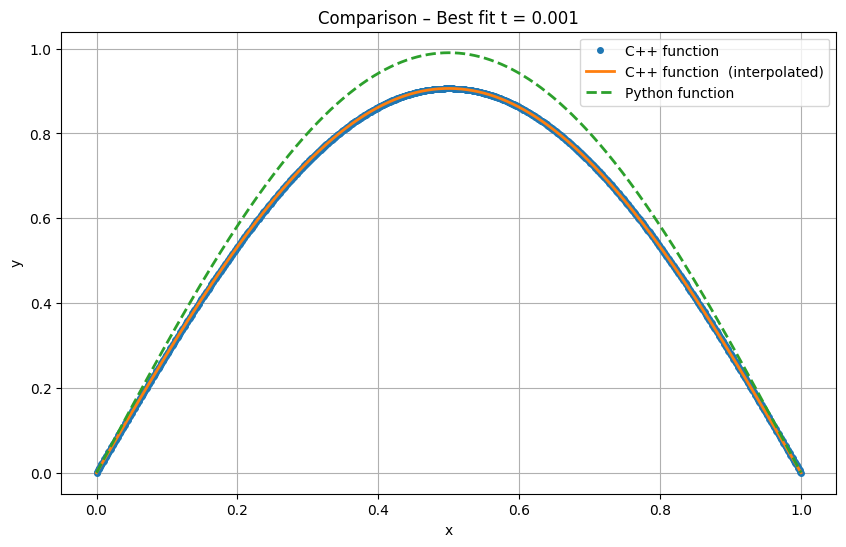

In [8]:
import csv
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# -------- 1. Read CSV data (your first snippet) --------
x1 = []
y1 = []
with open('out.csv', 'r') as csvfile:
    plots = csv.reader(csvfile, delimiter=',')
    for row in plots:
        x1.append(float(row[0]))
        y1.append(float(row[1]))

# Convert to numpy arrays
x1 = np.array(x1)
y1 = np.array(y1)

# -------- 2. Generate theoretical curves (your second snippet) --------
PI = math.pi
numPoints = 10000
alpha = 1.0
t_values = [0.001, 0.1, 0.5, 0.7, 1.0, 2.0]
#t_values = [0.01]

# Common x grid for theoretical curves (0 to 1)
x2 = np.linspace(0, 1, numPoints + 1)

# Store all theoretical y2 curves in a dictionary
theoretical_curves = {}
for n in t_values:
    y2 = [math.sin(PI * xi) * math.exp(-alpha * PI * PI * n) for xi in x2]
    theoretical_curves[n] = np.array(y2)

# -------- 3. Interpolate CSV data onto the theoretical x grid --------
# Create an interpolation function from CSV points
interp_func = interp1d(x1, y1, kind='linear', fill_value='extrapolate')
y1_interp = interp_func(x2)   # now y1_interp has same shape as y2

# -------- 4. Compute RMSE for each theoretical curve ----------
rmse_values = {}
for n, y2 in theoretical_curves.items():
    diff = y1_interp - y2
    rmse = np.sqrt(np.mean(diff**2))
    rmse_values[n] = rmse
    print(f"t = {n:5.3f}   RMSE = {rmse:.6f}")

# Find best matching t
best_t = min(rmse_values, key=rmse_values.get)
print(f"\nBest match: t = {best_t} with RMSE = {rmse_values[best_t]:.6f}")

# -------- 5. Visual comparison (CSV vs best theoretical curve) --------
plt.figure(figsize=(10, 6))
plt.plot(x1, y1, 'o', markersize=4, label='C++ function')
plt.plot(x2, y1_interp, '-', linewidth=2, label='C++ function  (interpolated)')
plt.plot(x2, theoretical_curves[best_t], '--', linewidth=2,
         label='Python function')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Comparison – Best fit t = {best_t}')
plt.legend()
plt.grid(True)
plt.show()